In [1]:
import pandas as pd
import warnings
import numpy as np
warnings.filterwarnings("ignore")

## Estrazione dati da MongoDB

In [2]:
from pymongo import MongoClient
from dotenv import load_dotenv
import os

In [97]:
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

client = MongoClient(MONGO_URI)
db=client["PolymerPrediction"]
collection=db["biceranoPolymers"]
target="glass_cte"

#print(collection.count_documents({}))

In [98]:
docs = list(collection.find({}))
df = pd.DataFrame(docs)

# espando il dizionario "properties"
prop_df = pd.json_normalize(df["properties"])

# integro nel dataframe
df = pd.concat([df.drop(columns=["properties"]), prop_df], axis=1)

# rimuovo righe senza SMILES o Tg
df = df.dropna(subset=["smiles", target])
df = df[~df["smiles"].str.contains(r"\[\[", na=False)].copy()
df.head()

,_id,polymer_name,smiles,bigsmiles,source_dataset,Tg,density,Tc,glass_cte,rubber_cte
7,698ddceeb7014ee539b3ac43,Poly(4-methyl-1-pentene),[*]CC(CC(C)C)[*],None,biceranoPolymers,302,0.838,None,484.398992,1135.584703
8,698ddceeb7014ee539b3ac44,Poly(vinyl formate),[*]CC(OC(=O))[*],None,biceranoPolymers,304,NaN,None,257.104588,680.999709
9,698ddceeb7014ee539b3ac57,Poly(p-n-butoxy styrene),[*]CC(C1=CC=C(C=C1)OCCCC)[*],None,biceranoPolymers,320,NaN,None,469.784059,1163.018947
10,698ddceeb7014ee539b3ac5c,Poly(8-aminocaprylic acid),[*]NCCCCCCCC(=O)[*],None,biceranoPolymers,324,1.083,None,406.119714,1271.147579
11,698ddceeb7014ee539b3ac61,Poly(methyl-p-xylylene),[*]CC1=CC=C(C(C)=C1)C[*],None,biceranoPolymers,328,NaN,None,267.843904,976.171269


## Integrazione descrittori RDKit

In [99]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np

descriptor_names = [desc[0] for desc in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
# print(descriptor_names)

def rdkit_descr(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return {d: np.nan for d in descriptor_names}
    values = calc.CalcDescriptors(mol)
    return dict(zip(descriptor_names, values))

desc_df = df["smiles"].apply(rdkit_descr).apply(pd.Series)
desc_df.head()

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
7,2.351667,0.704722,2.351667,0.704722,0.492023,84.162,72.066,84.093900,36.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9.619722,0.280833,9.619722,0.280833,0.438566,72.063,68.031,72.021129,28.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,5.650807,0.485248,5.650807,0.485248,0.603310,176.259,160.131,176.120115,70.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10,10.688309,0.006783,10.688309,0.006783,0.518339,141.214,126.094,141.115364,58.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
11,2.393009,0.548037,2.393009,0.548037,0.557487,118.179,108.099,118.078250,46.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


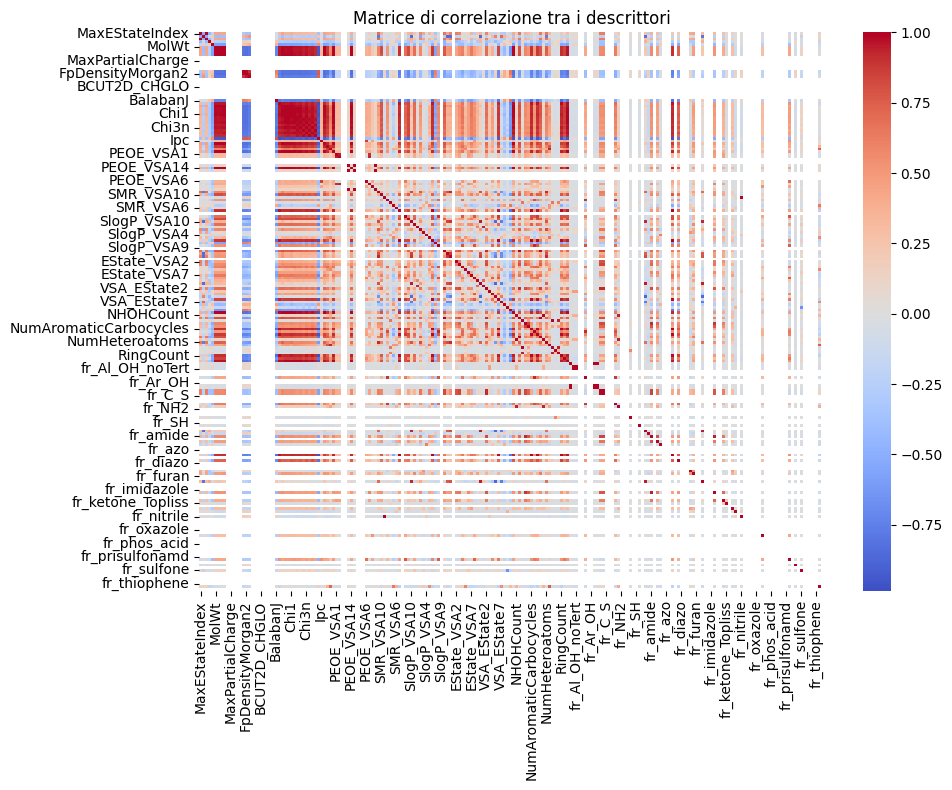

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = desc_df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra i descrittori")
plt.tight_layout()
plt.show()

## Aggiunta Fingerprint

In [100]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def morgan_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*1024
    fp = morgan_gen.GetFingerprint(mol)  
    return list(fp)

fp_df = df["smiles"].apply(morgan_fp).apply(pd.Series)
fp_df.columns = [f"fp_{i}" for i in range(fp_df.shape[1])]

In [101]:
from rdkit.Chem import MACCSkeys

def maccs_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*167  # MACCS ha 167 bit (indice 0 inutilizzato)
    fp = MACCSkeys.GenMACCSKeys(mol)
    return list(fp)
maccs_df = df["smiles"].apply(maccs_fp).apply(pd.Series)
maccs_df.columns=[f"maccs_{i}" for i in range(167)]

feature_df = pd.concat([desc_df, fp_df, maccs_df], axis=1)

## Mordred

In [102]:
from mordred import Calculator, descriptors

# calcolatore Mordred 
calc = Calculator(descriptors, ignore_3D=True)

mols = []
valid_idx = []

for i, s in df["smiles"].items():
    mol = Chem.MolFromSmiles(s)
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)

# calcolo descrittori
mordred_df = calc.pandas(mols)
mordred_df.index = valid_idx

print(mordred_df.shape)

# rimuove colonne tutte NaN
mordred_df = mordred_df.dropna(axis=1, how="all")

# converte tutto a numerico (NaN dove non convertibile)
mordred_df = mordred_df.apply(pd.to_numeric, errors="coerce")


 13%|██████████▉                                                                      | 30/223 [00:04<00:43,  4.45it/s]

C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 30%|████████████████████████▋                                                        | 68/223 [00:05<00:05, 25.84it/s]

C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 31%|█████████████████████████▍                                                       | 70/223 [00:05<00:05, 25.84it/s]

...

C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 87%|█████████████████████████████████████████████████████████████████████▏          | 193/223 [00:07<00:00, 50.66it/s]

C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|████████████████████████████████████████████████████████████████████████████████| 223/223 [00:07<00:00, 28.74it/s]


C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
(223, 1613)


In [103]:
feature_df = feature_df.loc[valid_idx]
feature_df = feature_df.loc[valid_idx]

X_base = feature_df.copy()       
X_mordred = mordred_df.copy()
X_mordred.index = feature_df.index
feature_df = pd.concat([X_base, X_mordred], axis=1)

## Pulizia dei dati

In [104]:
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
feature_df = feature_df.fillna(feature_df.median(numeric_only=True))
feature_df = feature_df.dropna(axis=1, how="all")

# rimuovo colonne costanti (con varianza 0) 
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.0)
sel.fit(feature_df)

mask = sel.get_support()
feature_df = feature_df.loc[:, mask]

print("Shape:", feature_df.shape[1])

Shape: 1497


In [105]:
# rimozione duplicati

#print( feature_df.shape)
dup = feature_df.columns.to_numpy()[feature_df.columns.duplicated()]
#print( dup)
feature_df.drop(columns=dup,inplace=True)
res1 =  np.unique(feature_df.columns,return_counts=True)
#print(res1)

## Preparazione dataset (separazione target)

In [106]:
# usa solo le righe valide (quelle per cui MolFromSmiles != None)
df_valid = df.loc[valid_idx].copy()

y = df_valid[target]
X = feature_df.copy()

X.index = df_valid["_id"]
y.index = df_valid["_id"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Index aligned:", (X.index == y.index).all())

X_np = np.ascontiguousarray(X.to_numpy(), dtype=np.float32)

print("dtype:", X_np.dtype)
print("contiguous:", X_np.flags['C_CONTIGUOUS'])
print("finite:", np.isfinite(X_np).all())
print("max abs:", np.max(np.abs(X_np)))

Shape X: (223, 1401)
Shape y: (223,)
Index aligned: True
dtype: float32
contiguous: True
finite: True
max abs: 92832150000000.0


## Feature selection

### Mutual Info Regression

In [125]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
random_state=28

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

# MI solo sul train
mi_scores = mutual_info_regression(X_train, y_train, random_state=random_state)

mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# seleziono top N
N = 300
top_features_mi = mi_series.head(N).index

# applico selezione a train e test
X_train_mi = X_train[top_features_mi]
X_test_mi = X_test[top_features_mi]

print("Shape train dopo MI:", X_train_mi.shape)
print("Shape test dopo MI:", X_test_mi.shape)
print("Feature scelte (MI):", len(top_features_mi))

Shape train dopo MI: (178, 300)
Shape test dopo MI: (45, 300)
Feature scelte (MI): 300


In [126]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model_mi = GradientBoostingRegressor(random_state=random_state)
model_mi.fit(X_train_mi, y_train)

pred_mi = model_mi.predict(X_test_mi)

print("MAE:", mean_absolute_error(y_test, pred_mi))
print("R²:", r2_score(y_test, pred_mi))


MAE: 42.65356422011494
R²: 0.5688299594738955


### Permutation importance
Uso il modello del passaggio precedente perché serve un modello già addestrato e abbastanza buono

In [127]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model_mi, X_train_mi, y_train, n_repeats=20, random_state=random_state)
perm_series = pd.Series(perm.importances_mean, index=X_train_mi.columns)
perm_series = perm_series.sort_values(ascending=False)

# selezione feature
thr = perm_series.mean()
selected = perm_series[perm_series > thr].index

X_train_perm = X_train_mi[selected]
X_test_perm = X_test_mi[selected]

print("Feature scelte (Permutation Importance):", X_train_perm.shape[1])


Feature scelte (Permutation Importance): 48


In [128]:

model_perm = GradientBoostingRegressor(random_state=random_state)
model_perm.fit(X_train_perm, y_train)

pred_perm = model_perm.predict(X_test_perm)

print("MAE:", mean_absolute_error(y_test, pred_perm))
print("R²:", r2_score(y_test, pred_perm))


MAE: 39.65834550146325
R²: 0.6396570489871571


## Cross validation finale

In [129]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=random_state)

# Cross-validation 5 fold
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Grid search
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_perm, y_train)

# Risultati tuning
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

# 8. Valutazione finale su test set
best_model = grid_search.best_estimator_
pred = best_model.predict(X_test_perm)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("\nPerformance on Test Set:")
print(f"MAE: {mae}")
print(f"R² : {r2}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 400, 'subsample': 0.8}

Best CV MAE:
31.70434957898967

Performance on Test Set:
MAE: 40.066175341478356
R² : 0.6472910839813423


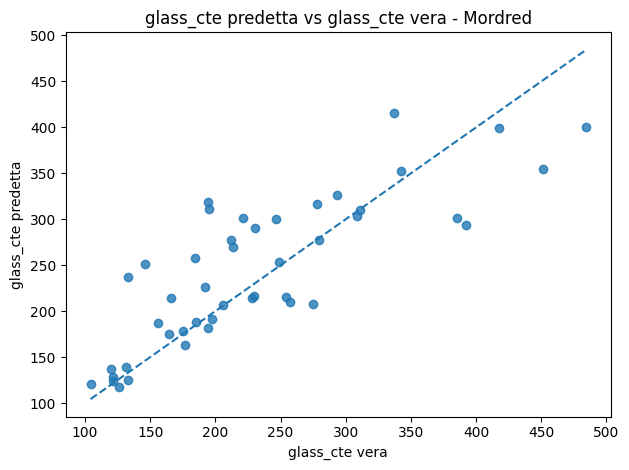

In [130]:
from matplotlib import pyplot as plt
plt.figure()
plt.scatter(y_test, pred, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel(f"{target} vera")
plt.ylabel(f"{target} predetta")
plt.title(f"{target} predetta vs {target} vera - Mordred")

plt.tight_layout()
plt.show()

### UMAP

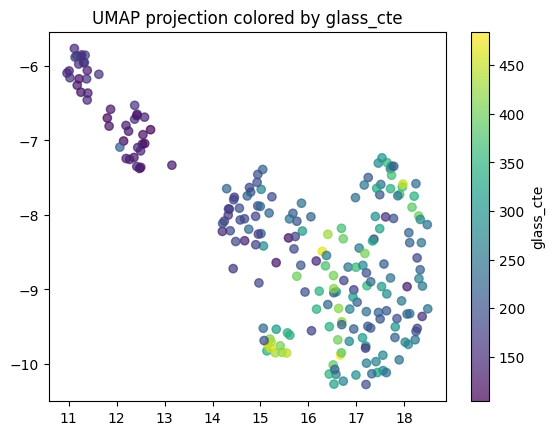

In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.scatter(X_umap[:,0], X_umap[:,1], c=y, alpha=0.7)
plt.colorbar(label=target)
plt.title(f"UMAP projection colored by {target}")
plt.show()

In [27]:
from sklearn.cluster import KMeans

labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_umap)

In [28]:
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df_umap["cluster"] = labels
df_umap[target] = y.values

df_umap.groupby("cluster")[target].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,214.0,308.981308,75.346708,130.0,239.25,319.0,373.00,482.0
1,90.0,483.222222,98.073325,255.0,412.00,485.5,561.75,685.0


In [29]:
X_clustered = X.copy()
X_clustered["cluster"] = labels

cluster_means = X_clustered.groupby("cluster").mean()
(cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False).head(10)

Ipc      1.833655e+12
WPath    4.377551e+03
ATS4Z    2.140964e+03
ATS5Z    2.057741e+03
ATS3Z    2.003053e+03
ATS6Z    1.924355e+03
VR1_A    1.772396e+03
ATS7Z    1.758461e+03
ATS2Z    1.669814e+03
ATS8Z    1.564582e+03
dtype: float64

In [ ]:
from sklearn.preprocessing import StandardScaler

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns,
    index=X.index
)
X_clustered = X_scaled.copy()
X_clustered["cluster"] = labels

cluster_means = X_clustered.groupby("cluster").mean()
(cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False).head(10)

### Univariate regression - Analisi dei descrittori (solo per esplorazione)

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

scores = []

for col in X.columns:
    X_col = X[[col]] 
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_col, y, test_size=0.2, random_state=random_state
    )
    
    model = RandomForestRegressor(n_estimators=200, random_state=random_state)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    scores.append({
        "feature": col,
        "MAE": mae,
        "R2": r2
    })

import pandas as pd
results = pd.DataFrame(scores)
results_sorted = results.sort_values("MAE")
results_sorted.head(20)

KeyboardInterrupt: 

In [ ]:
results.sort_values("R2", ascending=False).head(20)

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,12))
sns.barplot(data=results_sorted.head(25), x="MAE", y="feature")
plt.title("Top 25 descrittori per MAE (più basso = migliore)")
plt.show()
